# **Notebook 4g: Evaluation of weak labels**

Evaluates the generated weak labels on test dataset.

## 1. Importing packages

In [1]:
import os
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score

Mounted at /content/drive
Working dir: /content/drive/MyDrive/Individual thesis part/Model 3: handlabeled + weak_labels


## 2. Preparation

In [2]:
MODEL_DIR      = "./model_labeling"
FEATURES_TEST  = "./Data_with_features/features_test.csv"
LABEL_COL      = "unnecessary"

## 3. Loading data and model

In [3]:
## 3. Load LR1 model + scaler + feature cols + thresholds
lr1_model  = joblib.load(os.path.join(MODEL_DIR, "lr1_labeling_model.joblib"))
lr1_scaler = joblib.load(os.path.join(MODEL_DIR, "lr1_scaler.joblib"))

with open(os.path.join(MODEL_DIR, "lr1_feature_cols.json")) as f:
    lr1_cols = json.load(f)

with open(os.path.join(MODEL_DIR, "lr1_thresholds.json")) as f:
    thresholds = json.load(f)

T_unnecessary = thresholds["T_unnecessary"]
T_necessary   = thresholds["T_necessary"]

print(f"T_unnecessary : {T_unnecessary}")
print(f"T_necessary   : {T_necessary}")

T_unnecessary : 0.96
T_necessary   : 0.31


## 4. Generating test predictions

In [4]:
# Loading test features and generate probabilities
test_df = pd.read_csv(FEATURES_TEST)
X_test  = test_df[lr1_cols].copy()
test_probs  = lr1_model.predict_proba(lr1_scaler.transform(X_test))[:, 1]
test_labels = test_df[LABEL_COL].astype(int).values
print(f"Test sentences: {len(test_probs)}")

Test sentences: 481


In [5]:
# Applying thresholds (label filtering)
weak = np.full(len(test_probs), np.nan)
weak[test_probs >= T_unnecessary] = 1
weak[test_probs <= T_necessary]   = 0

mask_labeled = ~np.isnan(weak)
n_labeled = mask_labeled.sum()
n_abstain  = (~mask_labeled).sum()

print(f"Labeled:  {n_labeled} ({n_labeled/len(weak):.1%})")
print(f"Abstained: {n_abstain} ({n_abstain/len(weak):.1%})")

Labeled:  258 (53.6%)
Abstained: 223 (46.4%)


## 5. Evaluation

In [10]:
# Evaluating label quality on labeled subset only
weak_labeled = weak[mask_labeled].astype(int)
labels_labeled = test_labels[mask_labeled]

print("\nLabel quality on test set (labeled sentences only):")
precision = precision_score(labels_labeled, weak_labeled, average=None)
print(f"Precision necessary (0)    : {precision[0]:.3f}")
print(f"Precision non-content (1)  : {precision[1]:.3f}")

print(f"Label quality summary:")
print(f"  Labeled              : {n_labeled} ({n_labeled/len(weak):.1%})")
print(f"  Abstained            : {n_abstain} ({n_abstain/len(weak):.1%})")
print(f"  Target precision     : {thresholds['target_precision']}")
print(f"  T_unnecessary        : {T_unnecessary}")
print(f"  T_necessary          : {T_necessary}")


Label quality on test set (labeled sentences only):
Precision necessary (0)    : 0.927
Precision non-content (1)  : 1.000
Label quality summary:
  Labeled              : 258 (53.6%)
  Abstained            : 223 (46.4%)
  Target precision     : 0.95
  T_unnecessary        : 0.96
  T_necessary          : 0.31


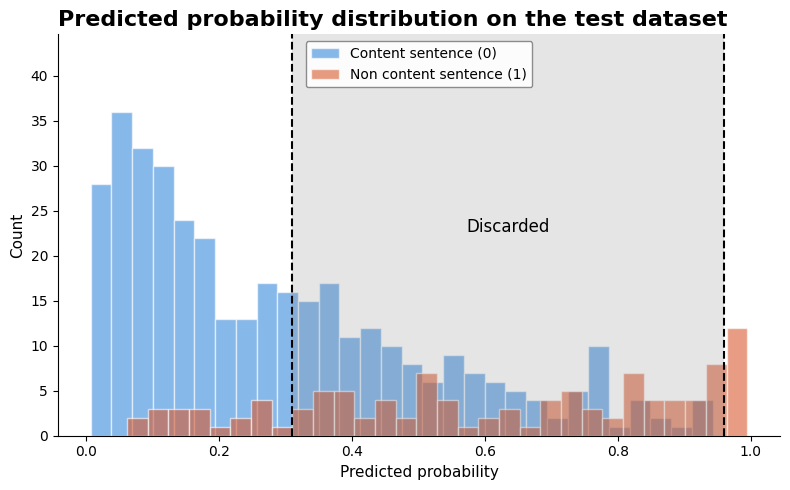

In [11]:
# Probability distribution
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(test_probs[test_labels == 0], bins=30, alpha=0.6,
        label="Content sentence (0)", color="#378ADD", edgecolor="white")
ax.hist(test_probs[test_labels == 1], bins=30, alpha=0.6,
        label="Non content sentence (1)", color="#D85A30", edgecolor="white")

ax.axvline(T_necessary, linestyle="--", color="black", linewidth=1.5)
ax.axvline(T_unnecessary, linestyle="--", color="black", linewidth=1.5)
ax.axvspan(T_necessary, T_unnecessary, facecolor="gray", alpha=0.2)

ymax = ax.get_ylim()[1]
ax.text((T_necessary + T_unnecessary) / 2, ymax * 0.60, "Discarded",
        ha="center", fontsize=12, color="black")

ax.set_ylim(0, ymax * 1.18)
ax.set_xlabel("Predicted probability", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Predicted probability distribution on the test dataset", fontsize=16, loc = "left", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=True, fontsize=10, loc="upper center", facecolor="white", edgecolor="gray", framealpha=0.9)
plt.tight_layout()
plt.show()